# Retail Sales Analysis - Python & Pandas

Analysis of Superstore sales data to uncover regional performance,
category profitability, discount impact, and seasonal trends.

**Tools:** Python, Pandas, Matplotlib | **Dataset:** Kaggle Superstore Sales

In [1]:
import pandas as pd
df = pd.read_csv("superstore_data.csv", encoding="latin1")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [2]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
# Q1: Which region generates the highest Sales and Profit?

Region_wise_sales_and_profit = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit',ascending=False)
print(Region_wise_sales_and_profit)


               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


**Insight:** The West region generates the highest profit,
while Central lags behind. The business could focus marketing
efforts on underperforming regions or study what the top region does differently.

In [8]:
# Q2: Which product category is most profitable?

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


**Insight:** Technology category drives the most profit,
while Furniture contributes the least. This suggests inventory
and marketing budget should be weighted more toward high-performing categories.

In [10]:
# Q3: Does higher discount lead to lower profit?

discount_profit = df.groupby('Discount')['Profit'].mean()
print(discount_profit)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


**Insight** :Profit stays healthy up to a 20% discount, but beyond 30%
discount, average profit turns negative and worsens sharply (down to
-₹310 at 50% discount). The business should avoid discounts above
20-25% unless there's a strategic reason, as they are actively eroding profit.

In [11]:
# Q4: Which Sub-Category should the business focus on more?

Lowest_sub_category_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(Lowest_sub_category_profit)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


**Insight:** Copiers generates the highest profit and should
get more inventory/marketing focus. Tables shows losses,
indicating the business should either reduce discounts on it or
reconsider stocking it.

In [12]:
# Q5: Does Ship Mode affect profit?

Ship_mode_summary = df.groupby('Ship Mode')['Profit'].mean()
print(Ship_mode_summary)

Ship Mode
First Class       31.839948
Same Day          29.266591
Second Class      29.535545
Standard Class    27.494770
Name: Profit, dtype: float64


**Insight:** First Class shows the best average profit margin,
suggesting the company may want to encourage customers toward this
shipping option, or review costs on the less profitable modes.

In [13]:
# Q6: Which customer segment contributes the most profit?

segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
print(segment_profit)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


**Insight:** The Consumer segment contributes the most profit,
making it the priority segment for retention and targeted offers.
Home Office contributes least, suggesting a need for a different
strategy or pricing there.

In [26]:
# Q7: Monthly Sales Trend

df['order_date'] = pd.to_datetime(df['Order Date'])
df['Month']= df['order_date'].dt.to_period('M')
monthly_profit = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print(monthly_profit)

Month
2017-11    118447.8250
2016-12     96999.0430
2017-09     87866.6520
2017-12     83829.3188
2014-09     81777.3508
2016-11     79411.9658
2014-11     78628.7167
2017-10     77776.9232
2015-11     75972.5635
2015-12     74919.5212
2016-09     73410.0249
2014-12     69545.6205
2015-09     64595.9180
2017-08     63120.8880
2016-10     59687.7450
2017-03     58872.3528
2016-05     56987.7280
2014-03     55691.0090
2017-06     52981.7257
2016-03     51715.8750
2017-07     45264.4160
2017-05     44261.1102
2017-01     43971.3740
2016-06     40344.5340
2016-07     39261.9630
2016-04     38750.0390
2015-03     38726.2520
2015-08     36898.3322
2017-04     36521.5361
2014-06     34595.1276
2015-04     34195.2085
2014-07     33946.3930
2014-10     31453.3930
2015-10     31404.9235
2016-08     31115.3743
2015-05     30131.6865
2015-07     28765.3250
2014-04     28295.3450
2014-08     27909.4685
2015-06     24797.2920
2014-05     23648.2870
2016-02     22978.8150
2017-02     20301.1334
2016-



**Insight:** November and December consistently rank among the highest
sales months across multiple years (2014-2017), with November 2017
recording the peak at ₹1,18,447. This points to a clear holiday-season
demand pattern. The business should plan inventory buildup and marketing
campaigns ahead of Q4 (Oct-Dec) each year to capitalize on this trend.

### Visualization: Profit by Region

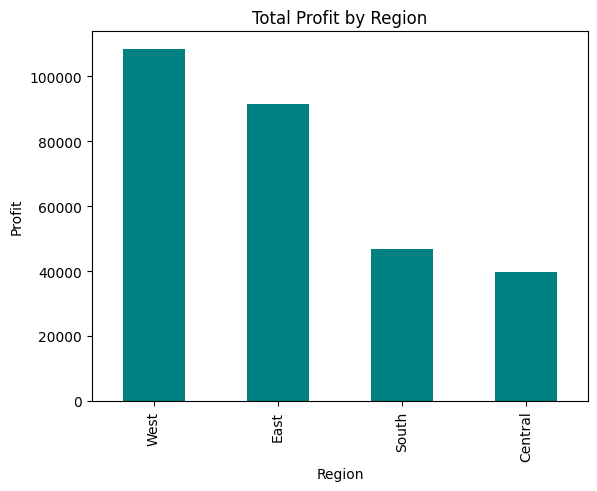

In [14]:
import matplotlib.pyplot as plt

Region_wise_sales_and_profit['Profit'].plot(kind='bar', color='teal')
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

### Visualizations: Discount VS Profit

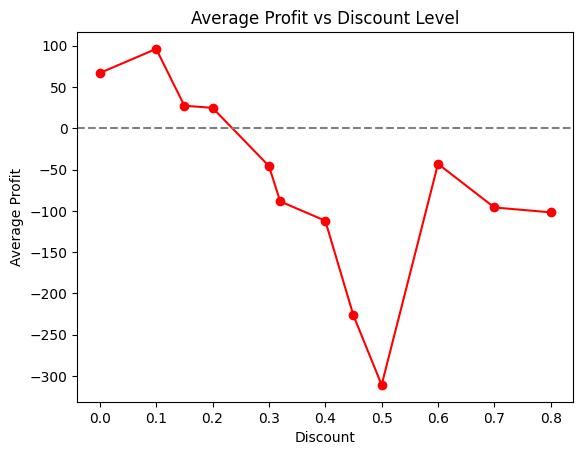

In [18]:
discount_profit.plot(kind='line', marker='o', color='red')
plt.title("Average Profit vs Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.axhline(0, color='gray', linestyle='--')
plt.show()

### Visualizations: Profit by Category

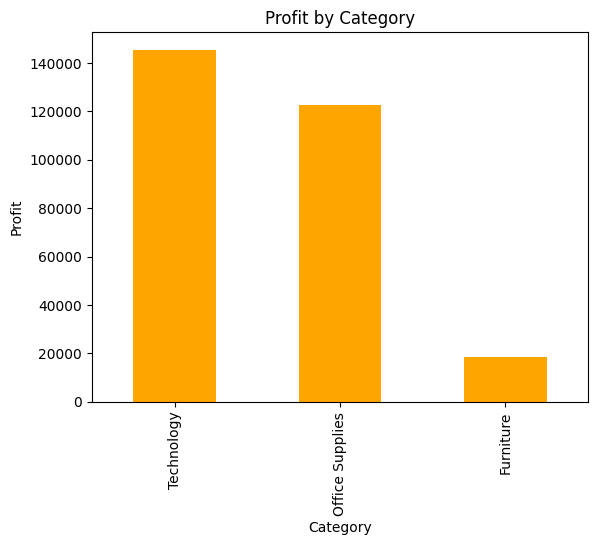

In [20]:
category_profit.plot(kind='bar', color='orange')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

### Visualizations: Month Wise Trend

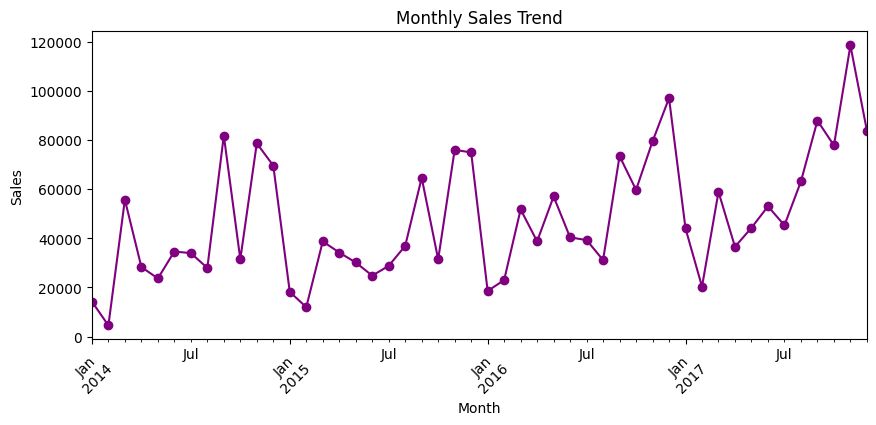

In [27]:
monthly_sales.plot(kind='line', marker='o', color='purple', figsize=(10,4))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()